## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_absolute_error

## Load Tesla Data

In [9]:


# Load the combined dataset
df = pd.read_csv("../data/processed/combined_data.csv")

# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Filter Tesla data
tsla = df[df["Ticker"] == "TSLA"].copy()

# Sort by date
tsla = tsla.sort_values("Date")

# Set Date as index
tsla.set_index("Date", inplace=True)

# Select the Close price
price = tsla["Close"]

price.head()

Date
2015-01-02    14.620667
2015-01-05    14.006000
2015-01-06    14.085333
2015-01-07    14.063333
2015-01-08    14.041333
Name: Close, dtype: float64

## Run Auto-ARIMA

In [11]:
from pmdarima import auto_arima

auto_model = auto_arima(
    price,
    seasonal=False,
    trace=True,
    error_action="ignore",
    suppress_warnings=True,
    stepwise=True
)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=19689.110, Time=3.04 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=19683.332, Time=0.09 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=19683.292, Time=0.46 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=19683.298, Time=0.62 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=19682.354, Time=0.07 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=19685.280, Time=0.72 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 5.097 seconds


 Train the Best Forecasting Model

The Auto-ARIMA model was trained using the complete Tesla closing price dataset. Based on the lowest AIC value, it selected **ARIMA(0,1,0)** as the best model for forecasting future stock prices.

## Generate Future Forecasts

In [12]:
future_days = 126

forecast, conf_int = auto_model.predict(
    n_periods=future_days,
    return_conf_int=True
)

c:\Users\admin\Desktop\10-academy\portfolio-optimization\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\admin\Desktop\10-academy\portfolio-optimization\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [13]:
forecast[:5]

2888    411.839996
2889    411.839996
2890    411.839996
2891    411.839996
2892    411.839996
dtype: float64

In [14]:
conf_int[:5]

array([[397.5088381 , 426.17115458],
       [391.57267799, 432.10731468],
       [387.01770214, 436.66229054],
       [383.17767986, 440.50231281],
       [379.79455232, 443.88544035]])

 Generate Future Forecasts

Using the trained Auto-ARIMA model, a **6-month (126 business days)** forecast was generated. The model also produced **95% confidence intervals** to estimate the range within which future Tesla stock prices are expected to fall.

## Create Future Dates

In [15]:
future_dates = pd.bdate_range(
    start=price.index[-1] + pd.Timedelta(days=1),
    periods=future_days
)

In [16]:
future_dates[:5]

DatetimeIndex(['2026-06-30', '2026-07-01', '2026-07-02', '2026-07-03',
               '2026-07-06'],
              dtype='datetime64[us]', freq='B')

 Create Future Business Dates

Future business dates were generated for the next **126 trading days** using `pd.bdate_range()`. Business days are used because stock markets are closed on weekends and holidays. These dates will be assigned to the forecasted Tesla stock prices for visualization and analysis.

## Create a Forecast DataFrame

In [19]:
future_forecast = pd.DataFrame({
    "Forecast": forecast.values,
    "Lower CI": conf_int[:, 0],
    "Upper CI": conf_int[:, 1]
}, index=future_dates)

future_forecast.head()

,Forecast,Lower CI,Upper CI
2026-06-30,411.839996,397.508838,426.171155
2026-07-01,411.839996,391.572678,432.107315
2026-07-02,411.839996,387.017702,436.662291
2026-07-03,411.839996,383.177680,440.502313
2026-07-06,411.839996,379.794552,443.885440


 Prepare the Future Forecast Data

A DataFrame was created to combine the forecasted Tesla stock prices with their corresponding **95% confidence intervals**. Future business dates were used as the index, making the forecast ready for visualization and analysis.

## Plot Historical Data and Future Forecast

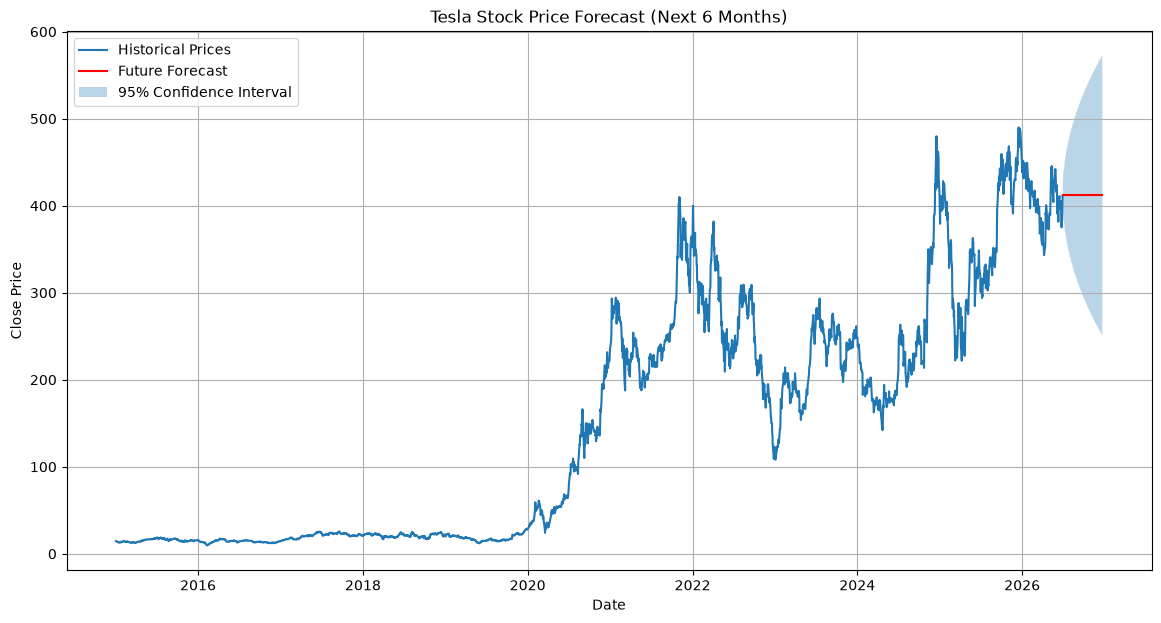

In [20]:
plt.figure(figsize=(14,7))

# Historical prices
plt.plot(price.index, price, label="Historical Prices")

# Forecast
plt.plot(
    future_forecast.index,
    future_forecast["Forecast"],
    color="red",
    label="Future Forecast"
)

# Confidence intervals
plt.fill_between(
    future_forecast.index,
    future_forecast["Lower CI"],
    future_forecast["Upper CI"],
    alpha=0.3,
    label="95% Confidence Interval"
)

plt.title("Tesla Stock Price Forecast (Next 6 Months)")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True)

plt.show()

 Forecast Visualization

The historical Tesla closing prices and the 6-month future forecast were visualized together with the **95% confidence intervals**. The forecast remains nearly constant because the selected **Auto-ARIMA(0,1,0)** model behaves like a random walk. The widening confidence intervals indicate increasing uncertainty as the forecast horizon extends.

## Step 11: Trend Analysis (1–2 Paragraphs)

The 6-month Tesla stock price forecast generated by the Auto-ARIMA model indicates a relatively stable trend. The forecast remains close to the latest observed closing price because the selected **ARIMA(0,1,0)** model behaves like a random walk, using the most recent value as the best estimate for future prices.

The confidence intervals become wider as the forecast horizon increases, indicating that uncertainty grows over time. This suggests that short-term forecasts are generally more reliable than long-term forecasts, where unexpected market events and volatility can significantly affect stock prices.

## Market Opportunities and Risks

 Market Opportunities and Risks

### Opportunities

- The forecast suggests that Tesla's stock price is expected to remain relatively stable over the next six months.
- Investors may benefit if Tesla performs better than expected due to new products or favorable market conditions.
- The forecast provides useful information for medium-term portfolio planning.

### Risks

- Tesla remains a highly volatile stock, and unexpected market events may cause significant price changes.
- The forecast does not account for economic news, interest rate changes, or company-specific announcements.
- Long-term forecasts are subject to greater uncertainty, as shown by the widening confidence intervals.

## Forecast Reliability Assessment

## Forecast Reliability

The confidence intervals widen as the forecast extends further into the future, indicating increasing uncertainty. This means the model has greater confidence in short-term predictions than long-term predictions. Therefore, the forecast should be used as a decision-support tool rather than an exact prediction of future Tesla stock prices.

## Save the Forecast

In [21]:
future_forecast.to_csv(
    "../data/processed/tsla_future_forecast.csv"
)

print("Forecast saved successfully!")

Forecast saved successfully!


### Save Future Forecast

The forecasted Tesla stock prices and their 95% confidence intervals were saved as a CSV file. This allows the forecast results to be reused for portfolio optimization and further analysis.